<a href="https://colab.research.google.com/github/borawa/data-analysis-trends/blob/main/%EB%B6%84%EC%84%9D%EC%8B%A4%EC%8A%B5_1(%EC%82%BC%EC%A0%84%EC%9A%B0%EA%B4%B4%EB%A6%AC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance seaborn --quiet

In [ ]:
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import yfinance as yf

matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


In [ ]:

# 삼성전자(보통주) / 삼성전자 우선주
tickers = ["005930.KS", "005935.KS"]

df = yf.download(tickers, start="2005-09-29", end="2026-04-17")

# 종가만 추출
close = df["Close"]
close.columns = ["삼성전자", "삼성전자우"]

print(close.shape)
print(close.head())

/tmp/ipykernel_3083/1392724957.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2005-09-29", end="2026-04-17")
[*********************100%***********************]  2 of 2 completed

(5076, 2)
                   삼성전자        삼성전자우
Date                                
2005-09-29  8296.513672  5774.805664
2005-09-30  8226.556641  5787.552246
2005-10-03  8226.556641  5787.552246
2005-10-04  8436.417969  5838.543945
2005-10-05  8408.438477  5883.161621


In [ ]:
print("=== 기간 & 크기 ===")
print(close.shape)
print(close.index[[0, -1]]) # 첫날 / 마지막날

print("\n=== 기초 통계 ===")
print(close.describe().round(0))

print("\n=== 결측값 확인 ===")
print(close.isnull().sum())

=== 기간 & 크기 ===
(5076, 2)
DatetimeIndex(['2005-09-29', '2026-04-16'], dtype='datetime64[ns]', name='Date', freq=None)

=== 기초 통계 ===
           삼성전자     삼성전자우
count    5076.0    5076.0
mean    34464.0   27030.0
std     28683.0   23425.0
min      5760.0    3229.0
25%     11947.0    7603.0
50%     22080.0   15807.0
75%     52716.0   44652.0
max    217550.0  149000.0

=== 결측값 확인 ===
삼성전자     0
삼성전자우    0
dtype: int64


In [ ]:
close = close.dropna()
print(close.index[0])

2005-09-29 00:00:00


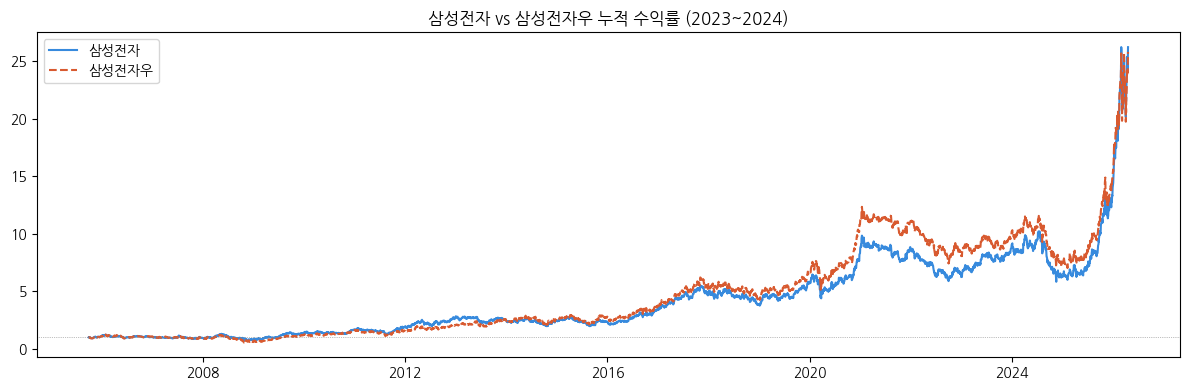

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 첫날 기준 누적 수익률 (첫날=1.0 → 1.10이면 +10%)
cum_return = close / close.iloc[0]

plt.figure(figsize=(12, 4))
plt.plot(cum_return["삼성전자"],  label="삼성전자",   color="#378ADD")
plt.plot(cum_return["삼성전자우"], label="삼성전자우", color="#D85A30", linestyle="--")
plt.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")
plt.title("삼성전자 vs 삼성전자우 누적 수익률 (2023~2024)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 일별 수익률 계산 (오늘 - 어제) / 어제
daily_return = close.pct_change().dropna()

# 상관계수 (1.0에 가까울수록 완전히 같이 움직임)
corr = daily_return.corr()
print(corr.round(4))

# 숫자로도 직접 확인
r = daily_return["삼성전자"].corr(daily_return["삼성전자우"])
print(f"\n상관계수: {r:.4f}")

         삼성전자   삼성전자우
삼성전자   1.0000  0.8129
삼성전자우  0.8129  1.0000

상관계수: 0.8129


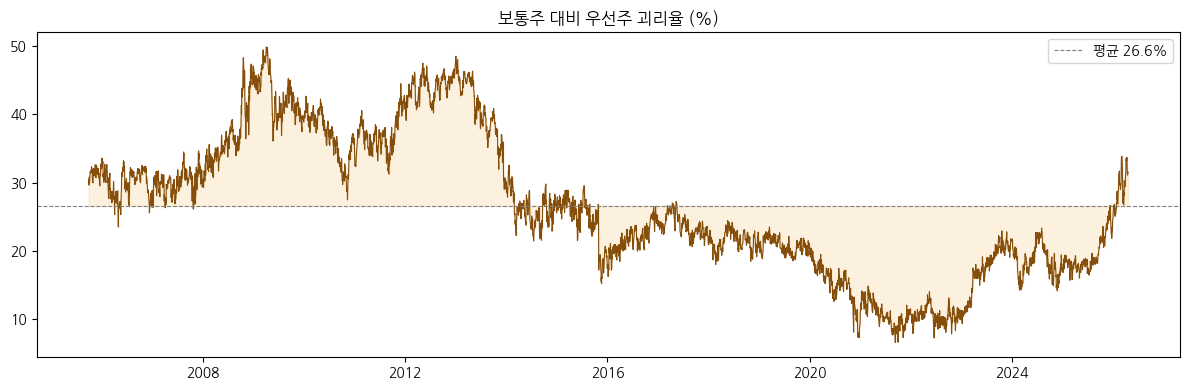

In [ ]:
# 괴리율 = (보통주 - 우선주) / 보통주 × 100
gap = (close["삼성전자"] - close["삼성전자우"]) / close["삼성전자"] * 100

plt.figure(figsize=(12, 4))
plt.plot(gap, color="#854F0B", linewidth=0.8)
plt.axhline(gap.mean(), color="gray", linestyle="--", linewidth=0.8, label=f"평균 {gap.mean():.1f}%")
plt.fill_between(gap.index, gap, gap.mean(), alpha=0.15, color="#EF9F27")
plt.title("보통주 대비 우선주 괴리율 (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 상위 5일 (괴리 가장 컸던 날)
top5 = gap.nlargest(5)
print("괴리율 상위 5일:")
print(top5.round(2))

# 하위 5일 (괴리 가장 작았던 날 = 우선주가 상대적으로 비쌌던 날)
bot5 = gap.nsmallest(5)
print("\n괴리율 하위 5일:")
print(bot5.round(2))

괴리율 상위 5일:
Date
2009-04-06    49.85
2009-04-03    49.84
2009-04-10    49.83
2009-04-07    49.55
2009-03-12    49.43
dtype: float64

괴리율 하위 5일:
Date
2021-09-09    6.56
2021-09-29    6.60
2022-06-16    7.22
2021-11-05    7.29
2020-12-22    7.29
dtype: float64


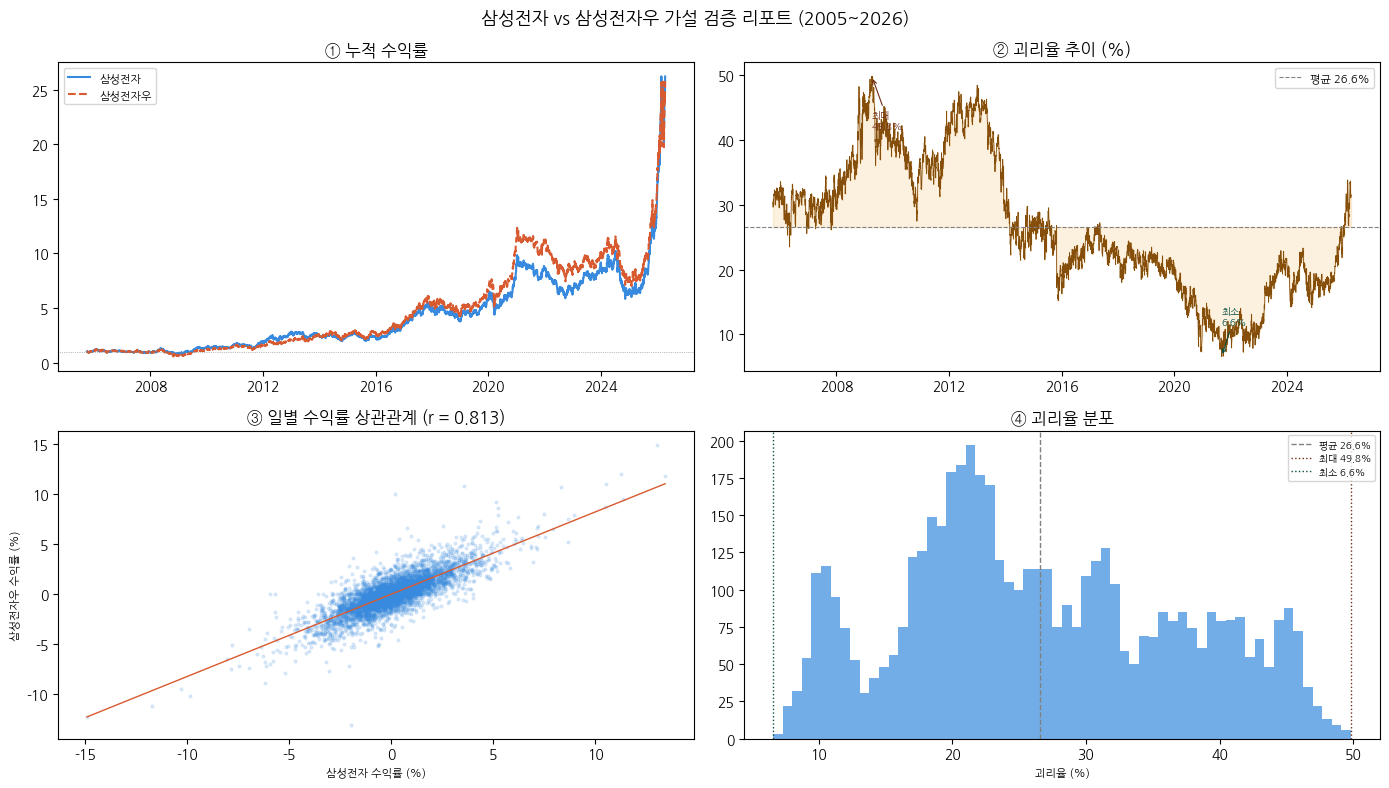

samsung_report.png 저장 완료


In [ ]:
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("삼성전자 vs 삼성전자우 가설 검증 리포트 (2005~2026)", fontsize=13)

# --- 차트 1: 누적 수익률 ---
ax1 = axes[0, 0]
cum = close / close.iloc[0]
ax1.plot(cum["삼성전자"],  label="삼성전자",  color="#378ADD")
ax1.plot(cum["삼성전자우"], label="삼성전자우", color="#D85A30", linestyle="--")
ax1.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")
ax1.set_title("① 누적 수익률")
ax1.legend(fontsize=8)

# --- 차트 2: 괴리율 추이 ---
ax2 = axes[0, 1]
gap = (close["삼성전자"] - close["삼성전자우"]) / close["삼성전자"] * 100
ax2.plot(gap, color="#854F0B", linewidth=0.6)
ax2.axhline(gap.mean(), color="gray", linestyle="--", linewidth=0.8,
            label=f"평균 {gap.mean():.1f}%")
ax2.fill_between(gap.index, gap, gap.mean(), alpha=0.15, color="#EF9F27")
# 최대·최소 지점 표시
ax2.annotate(f"최대\n{gap.max():.1f}%",
             xy=(gap.idxmax(), gap.max()),
             xytext=(gap.idxmax(), gap.max() - 8),
             fontsize=7, color="#712B13",
             arrowprops=dict(arrowstyle="->", color="#712B13", lw=0.8))
ax2.annotate(f"최소\n{gap.min():.1f}%",
             xy=(gap.idxmin(), gap.min()),
             xytext=(gap.idxmin(), gap.min() + 5),
             fontsize=7, color="#085041",
             arrowprops=dict(arrowstyle="->", color="#085041", lw=0.8))
ax2.set_title("② 괴리율 추이 (%)")
ax2.legend(fontsize=8)

# --- 차트 3: 일별 수익률 산점도 ---
ax3 = axes[1, 0]
daily = close.pct_change().dropna() * 100
ax3.scatter(daily["삼성전자"], daily["삼성전자우"],
            alpha=0.15, s=4, color="#378ADD")
# 추세선
m, b = np.polyfit(daily["삼성전자"], daily["삼성전자우"], 1)
x_line = np.linspace(daily["삼성전자"].min(), daily["삼성전자"].max(), 100)
ax3.plot(x_line, m * x_line + b, color="#D85A30", linewidth=1)
r = daily["삼성전자"].corr(daily["삼성전자우"])
ax3.set_title(f"③ 일별 수익률 상관관계 (r = {r:.3f})")
ax3.set_xlabel("삼성전자 수익률 (%)", fontsize=8)
ax3.set_ylabel("삼성전자우 수익률 (%)", fontsize=8)

# --- 차트 4: 괴리율 분포 히스토그램 ---
ax4 = axes[1, 1]
ax4.hist(gap, bins=60, color="#378ADD", alpha=0.7, edgecolor="none")
ax4.axvline(gap.mean(), color="gray",  linestyle="--", linewidth=1,
            label=f"평균 {gap.mean():.1f}%")
ax4.axvline(gap.max(),  color="#712B13", linestyle=":",  linewidth=1,
            label=f"최대 {gap.max():.1f}%")
ax4.axvline(gap.min(),  color="#085041", linestyle=":",  linewidth=1,
            label=f"최소 {gap.min():.1f}%")
ax4.set_title("④ 괴리율 분포")
ax4.set_xlabel("괴리율 (%)", fontsize=8)
ax4.legend(fontsize=7)

plt.tight_layout()
plt.savefig("samsung_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("samsung_report.png 저장 완료")


In [ ]:
print("=" * 50)
print("  삼성전자 vs 삼성전자우 가설 검증 결과")
print("=" * 50)

daily = close.pct_change().dropna()
r = daily["삼성전자"].corr(daily["삼성전자우"])
gap = (close["삼성전자"] - close["삼성전자우"]) / close["삼성전자"] * 100

print(f"\n[가설] 장기적으로 같이 움직이지만, 단기 괴리가 존재한다")
print(f"\n  상관계수        : {r:.4f}  → 매우 강한 동조")
print(f"  괴리율 평균     : {gap.mean():.1f}%")
print(f"  괴리율 최대     : {gap.max():.1f}%  ({gap.idxmax().date()})")
print(f"  괴리율 최소     : {gap.min():.1f}%  ({gap.idxmin().date()})")
print(f"  괴리율 표준편차 : {gap.std():.1f}%")

print(f"""
[해석]
  - 상관계수 {r:.2f}: 두 종목은 거의 동일하게 움직임 → 가설 1부 확인
  - 괴리율 범위 {gap.min():.1f}~{gap.max():.1f}%: 단기 괴리는 실제로 존재 → 가설 2부 확인
  - 최대 괴리({gap.idxmax().date()}): 글로벌 금융위기 직후 반등 구간
    → 유동성 낮은 우선주가 보통주 반등 속도를 따라가지 못함
  - 최소 괴리({gap.idxmin().date()}): 코로나 초저금리 시기
    → 배당 매력 부각으로 우선주에 자금 집중 유입
""")
print("=" * 50)

  삼성전자 vs 삼성전자우 가설 검증 결과

[가설] 장기적으로 같이 움직이지만, 단기 괴리가 존재한다

  상관계수        : 0.8129  → 매우 강한 동조
  괴리율 평균     : 26.6%
  괴리율 최대     : 49.8%  (2009-04-06)
  괴리율 최소     : 6.6%  (2021-09-09)
  괴리율 표준편차 : 10.3%

[해석]
  - 상관계수 0.81: 두 종목은 거의 동일하게 움직임 → 가설 1부 확인
  - 괴리율 범위 6.6~49.8%: 단기 괴리는 실제로 존재 → 가설 2부 확인
  - 최대 괴리(2009-04-06): 글로벌 금융위기 직후 반등 구간
    → 유동성 낮은 우선주가 보통주 반등 속도를 따라가지 못함
  - 최소 괴리(2021-09-09): 코로나 초저금리 시기
    → 배당 매력 부각으로 우선주에 자금 집중 유입



In [ ]:
print(f"최빈 구간 중심: {gap.mode()[0]:.1f}%")
print(f"중앙값: {gap.median():.1f}%")
print(f"평균:   {gap.mean():.1f}%")


최빈 구간 중심: 10.9%
중앙값: 25.0%
평균:   26.6%


In [ ]:
# 괴리율이 좁혀진 날, 보통주가 내린 건지 우선주가 오른 건지 확인
narrow = gap[gap < gap.mean()]  # 평균 이하 날들
print(close.loc[narrow.index].pct_change().mean())

삼성전자     0.001451
삼성전자우    0.001459
dtype: float64


In [ ]:
gap_before = gap[gap.index < "2020-01-01"]
gap_after  = gap[gap.index >= "2020-01-01"]

print(f"2020년 이전 평균 괴리율: {gap_before.mean():.1f}%")
print(f"2020년 이후 평균 괴리율: {gap_after.mean():.1f}%")

2020년 이전 평균 괴리율: 31.2%
2020년 이후 평균 괴리율: 15.9%


In [ ]:
# 기존 close에서 2019년 이후만 잘라냄 (재다운로드 불필요)
close_recent = close["2019-01-01":]

gap_recent = (close_recent["삼성전자"] - close_recent["삼성전자우"]) \
             / close_recent["삼성전자"] * 100

# 구간별 평균 괴리율 비교
gap_2019     = gap_recent["2019-01-01":"2020-02-28"]
gap_post2020 = gap_recent["2020-03-01":]

print(f"2019~코로나 이전  평균 괴리율: {gap_2019.mean():.1f}%  (기준선)")
print(f"2020-03 이후      평균 괴리율: {gap_post2020.mean():.1f}%")

2019~코로나 이전  평균 괴리율: 20.4%  (기준선)
2020-03 이후      평균 괴리율: 15.8%


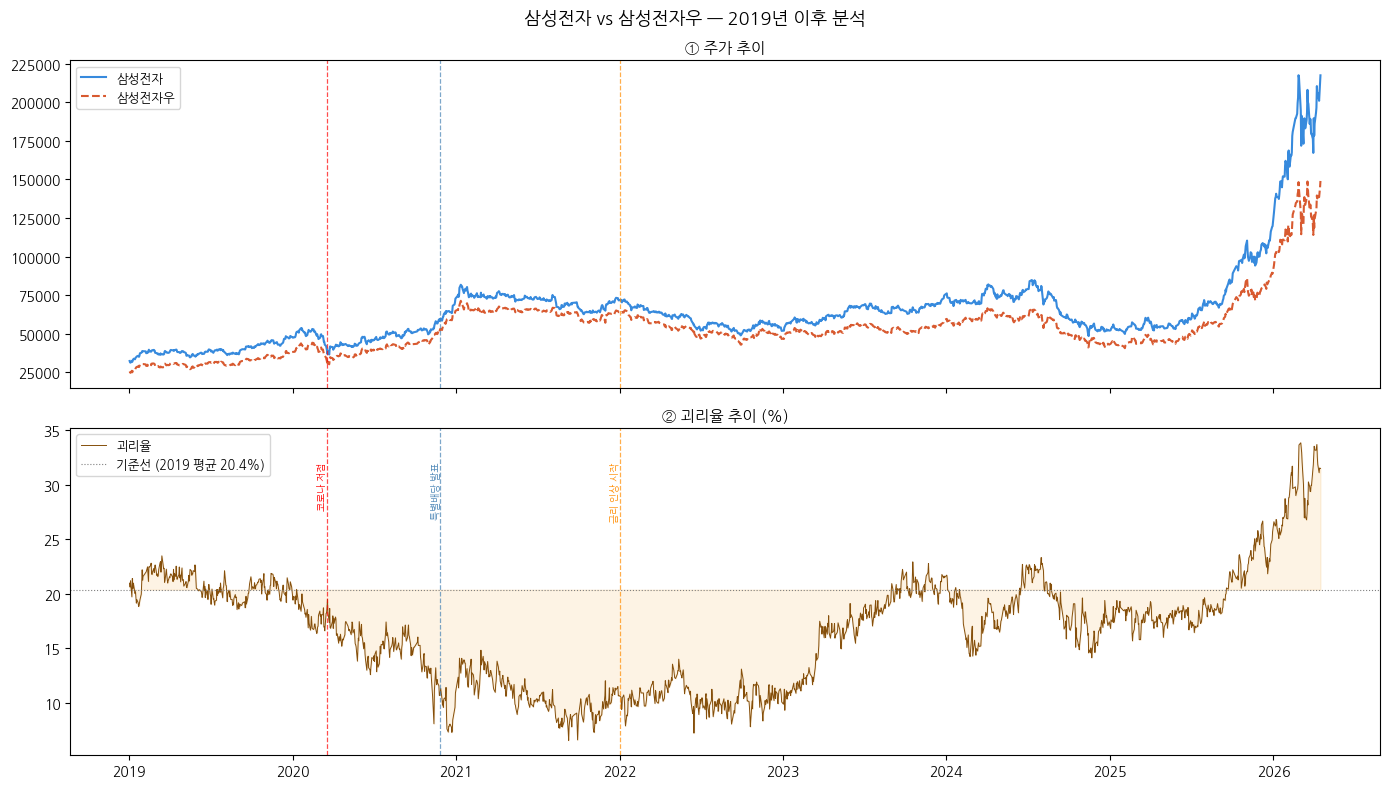

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("삼성전자 vs 삼성전자우 — 2019년 이후 분석", fontsize=13)

events = {
    "2020-03-19": ("코로나 저점",    "red"),
    "2020-11-26": ("특별배당 발표",  "steelblue"),
    "2022-01-01": ("금리 인상 시작", "darkorange"),
}

# --- 차트 1: 주가 추이 ---
ax1 = axes[0]
ax1.plot(close_recent["삼성전자"],  label="삼성전자",  color="#378ADD")
ax1.plot(close_recent["삼성전자우"], label="삼성전자우", color="#D85A30", linestyle="--")
ax1.set_title("① 주가 추이", fontsize=11)
ax1.legend(fontsize=9)

for date, (label, color) in events.items():
    ax1.axvline(pd.Timestamp(date), color=color,
                linewidth=0.9, linestyle="--", alpha=0.7)

# --- 차트 2: 괴리율 ---
ax2 = axes[1]
ax2.plot(gap_recent, color="#854F0B", linewidth=0.7, label="괴리율")
ax2.axhline(gap_2019.mean(), color="gray", linewidth=0.8, linestyle=":",
            label=f"기준선 (2019 평균 {gap_2019.mean():.1f}%)")
ax2.fill_between(gap_recent.index, gap_recent,
                 gap_2019.mean(), alpha=0.12, color="#EF9F27")
ax2.set_title("② 괴리율 추이 (%)", fontsize=11)
ax2.legend(fontsize=9)

for date, (label, color) in events.items():
    ax2.axvline(pd.Timestamp(date), color=color,
                linewidth=0.9, linestyle="--", alpha=0.7)
    ax2.text(pd.Timestamp(date), gap_recent.max() * 0.95,
             label, fontsize=7, color=color,
             rotation=90, va="top", ha="right")

plt.tight_layout()
plt.savefig("samsung_2019.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
구간 = {
    "2019 (기준선)":       ("2019-01-01", "2020-02-28"),
    "코로나 폭락~반등":    ("2020-03-01", "2020-11-25"),
    "특별배당~저금리":     ("2020-11-26", "2021-12-31"),
    "금리 인상기":         ("2022-01-01", "2022-12-31"),
    "최근 (2023~현재)":    ("2023-01-01", None),
}

print(f"{'구간':<22} {'평균':>6} {'최소':>6} {'최대':>6}  판단")
print("-" * 65)

baseline = gap_recent["2019-01-01":"2020-02-28"].mean()

for name, (start, end) in 구간.items():
    g = gap_recent[start:end] if end else gap_recent[start:]
    diff = g.mean() - baseline
    if diff > 3:
        판단 = "우선주 매력 ▲ (보통주 상대 과열)"
    elif diff < -3:
        판단 = "보통주 매력 ▲ or 우선주 급등"
    else:
        판단 = "중립"
    print(f"{name:<22} {g.mean():>5.1f}% {g.min():>5.1f}% {g.max():>5.1f}%  {판단}")

구간                         평균     최소     최대  판단
-----------------------------------------------------------------
2019 (기준선)              20.4%  16.4%  23.5%  중립
코로나 폭락~반등               15.2%   8.1%  19.5%  보통주 매력 ▲ or 우선주 급등
특별배당~저금리                10.5%   6.6%  14.8%  보통주 매력 ▲ or 우선주 급등
금리 인상기                  10.5%   7.2%  14.0%  보통주 매력 ▲ or 우선주 급등
최근 (2023~현재)            19.4%   9.3%  33.8%  중립


In [ ]:
# 최근 구간 괴리율 상위 10일
gap_recent_2023 = gap_recent["2023-01-01":]
top10 = gap_recent_2023.nlargest(10)

print("2023년 이후 괴리율 상위 10일:")
print(top10.round(1).to_string())

# 어느 달에 몰려 있는지도 확인
print(f"\n상위 10일 기간: {top10.index.min().date()} ~ {top10.index.max().date()}")

2023년 이후 괴리율 상위 10일:
Date
2026-03-03    33.8
2026-04-08    33.7
2026-02-27    33.6
2026-04-02    33.5
2026-03-04    33.4
2026-04-07    33.4
2026-04-03    33.2
2026-04-06    33.1
2026-03-05    32.9
2026-04-01    32.8

상위 10일 기간: 2026-02-27 ~ 2026-04-08


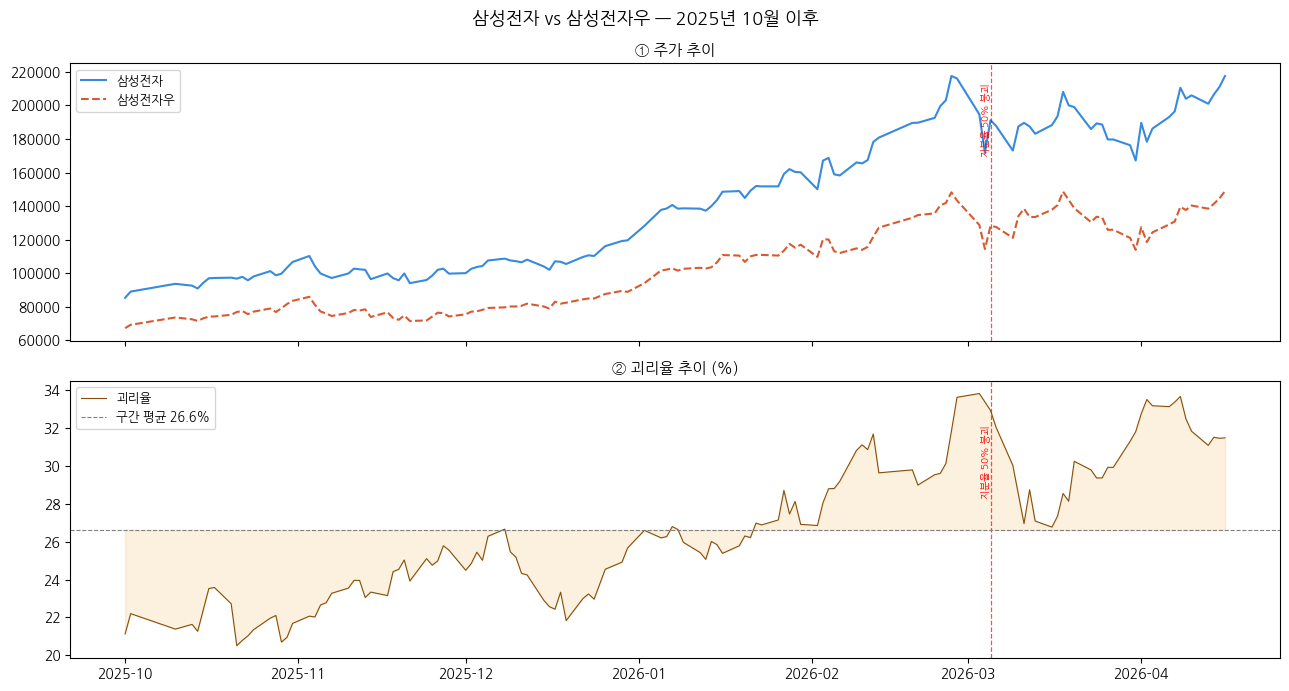

구간 평균 괴리율 : 26.6%
3월 5일 이후 평균: 30.6%
3월 5일 이전 평균: 25.4%


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2025-10-01 이후 구간
recent = close["2025-10-01":]
gap_recent_final = (recent["삼성전자"] - recent["삼성전자우"]) \
                   / recent["삼성전자"] * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle("삼성전자 vs 삼성전자우 — 2025년 10월 이후", fontsize=13)

# 차트 1: 주가 추이
ax1 = axes[0]
ax1.plot(recent["삼성전자"],   label="삼성전자",  color="#378ADD")
ax1.plot(recent["삼성전자우"], label="삼성전자우", color="#D85A30", linestyle="--")
ax1.set_title("① 주가 추이", fontsize=11)
ax1.legend(fontsize=9)

# 외국인 지분율 주요 시점 수직선 (뉴스 기반 수동 입력)
events = {
    "2025-11-xx": ("외국인 지분율 고점\n52.63%", "steelblue"),
    "2026-03-05": ("지분율 50% 붕괴",            "red"),
}
for date, (label, color) in events.items():
    if "xx" not in date:
        for ax in axes:
            ax.axvline(pd.Timestamp(date), color=color,
                       linewidth=0.9, linestyle="--", alpha=0.7)
        ax1.text(pd.Timestamp(date), recent["삼성전자"].max() * 0.98,
                 label, fontsize=7, color=color,
                 rotation=90, va="top", ha="right")

# 차트 2: 괴리율
ax2 = axes[1]
ax2.plot(gap_recent_final, color="#854F0B", linewidth=0.8, label="괴리율")
ax2.axhline(gap_recent_final.mean(), color="gray", linestyle="--",
            linewidth=0.8, label=f"구간 평균 {gap_recent_final.mean():.1f}%")
ax2.fill_between(gap_recent_final.index, gap_recent_final,
                 gap_recent_final.mean(), alpha=0.15, color="#EF9F27")
ax2.set_title("② 괴리율 추이 (%)", fontsize=11)
ax2.legend(fontsize=9)

# 3월 5일 수직선 라벨
ax2.text(pd.Timestamp("2026-03-05"), gap_recent_final.max() * 0.95,
         "지분율 50% 붕괴", fontsize=7, color="red",
         rotation=90, va="top", ha="right")

plt.tight_layout()
plt.savefig("samsung_recent.png", dpi=150, bbox_inches="tight")
plt.show()

# 수치 요약
print(f"구간 평균 괴리율 : {gap_recent_final.mean():.1f}%")
print(f"3월 5일 이후 평균: {gap_recent_final['2026-03-05':].mean():.1f}%")
print(f"3월 5일 이전 평균: {gap_recent_final[:'2026-03-04'].mean():.1f}%")

In [ ]:
print(recent["삼성전자"].idxmax().date())

2026-02-26


In [ ]:
from google.colab import files

# 'close' DataFrame을 CSV 파일로 저장합니다.
close.to_csv('samsung_stock_data.csv')

# 저장된 CSV 파일을 다운로드합니다.
files.download('samsung_stock_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>